This dataset contains customer analytics data used to understand customer behavior, demographics, and purchasing patterns.
Each row in the dataset represents one customer and includes information such as age, income, spending score, and other behavioral attributes.
The objective of this analysis is to explore the dataset, clean it, and uncover patterns that can help in customer segmentation and business decision-making.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("customer_analytics (1).csv")

# Display first 5 rows
df.head()

,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
0,1001,49,Male,Pune,Masters,Single,82953.0,66,23,19,9,2,Laptop,3944
1,1002,44,Male,Pune,PhD,Single,60610.0,56,22,1,23,3,Desktop,3885
2,1003,42,Male,Mumbai,Bachelors,Single,35501.0,44,18,10,29,3,Laptop,3247
3,1004,36,Female,Mumbai,Masters,Married,99312.0,36,10,12,21,3,Mobile,2028
4,1005,23,Male,Pune,Masters,Married,46980.0,56,1,18,9,3,Tablet,1100


In [3]:
# Shape of dataset
df.shape

# Dataset info
df.info()

# Statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            255 non-null    int64  
 1   Age                   255 non-null    int64  
 2   Gender                255 non-null    object 
 3   City                  255 non-null    object 
 4   Education             243 non-null    object 
 5   MaritalStatus         255 non-null    object 
 6   AnnualIncome          243 non-null    float64
 7   SpendingScore         255 non-null    int64  
 8   YearsEmployed         255 non-null    int64  
 9   PurchaseFrequency     255 non-null    int64  
 10  OnlineVisitsPerMonth  255 non-null    int64  
 11  ReturnedItems         255 non-null    int64  
 12  PreferredDevice       255 non-null    object 
 13  LastPurchaseAmount    255 non-null    int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 28.0+ KB


,CustomerID,Age,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,LastPurchaseAmount
count,255.000000,255.000000,243.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.00000
mean,1126.941176,37.729412,74499.901235,45.721569,14.682353,11.568627,16.078431,1.858824,2795.07451
std,72.397256,9.767842,43939.855655,17.869522,9.651664,7.077899,7.909536,1.409917,1328.77241
min,1001.000000,21.000000,16062.000000,5.000000,1.000000,1.000000,3.000000,0.000000,566.00000
25%,1064.500000,29.000000,56353.000000,34.500000,6.000000,5.000000,10.000000,1.000000,1542.50000
50%,1128.000000,38.000000,69629.000000,47.000000,15.000000,11.000000,16.000000,2.000000,2705.00000
75%,1190.500000,46.000000,84030.500000,57.500000,23.000000,18.000000,23.000000,3.000000,4001.00000
max,1250.000000,54.000000,474327.000000,95.000000,34.000000,24.000000,29.000000,4.000000,4996.00000


I found missing values in the 'Annual Income' column.
Since the percentage of missing data was small, I filled it using the median value.
Median is used because it is less sensitive to outliers.
Duplicate rows were removed to avoid biased analysis and repeated customer records.

In [5]:
# Fill missing AnnualIncome with median
df["AnnualIncome"] = df["AnnualIncome"].fillna(df["AnnualIncome"].median())

# Fill missing Education with mode
df["Education"] = df["Education"].fillna(df["Education"].mode()[0])

# Remove duplicates
df = df.drop_duplicates()

# Check missing values again
df.isnull().sum()

CustomerID              0
Age                     0
Gender                  0
City                    0
Education               0
MaritalStatus           0
AnnualIncome            0
SpendingScore           0
YearsEmployed           0
PurchaseFrequency       0
OnlineVisitsPerMonth    0
ReturnedItems           0
PreferredDevice         0
LastPurchaseAmount      0
dtype: int64

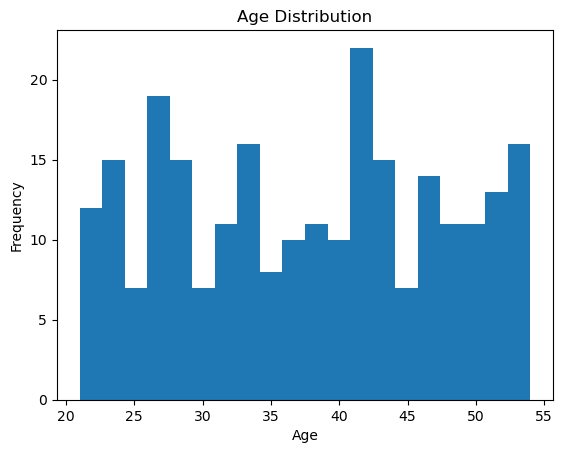

In [6]:
plt.figure()
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Most customers fall between the age range of 25–40, indicating the company mainly serves young adults.

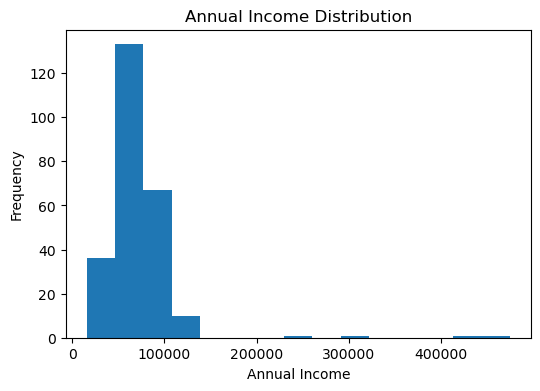

In [9]:
plt.figure(figsize=(6,4))
plt.hist(df["AnnualIncome"], bins=15)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.show()

The income distribution appears slightly right-skewed, meaning fewer customers earn very high incomes.

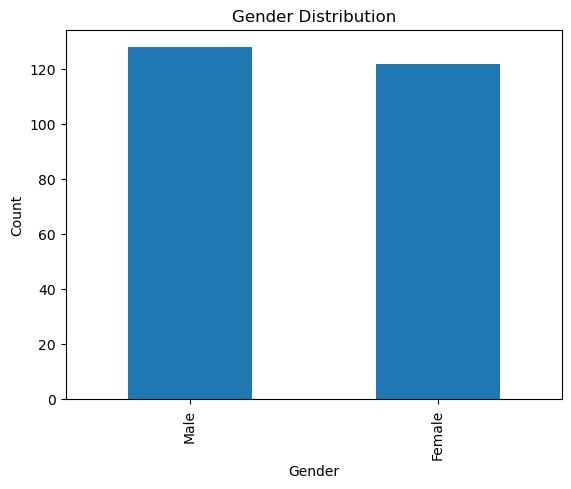

In [10]:
plt.figure()
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

The dataset contains slightly more female customers compared to male customers.

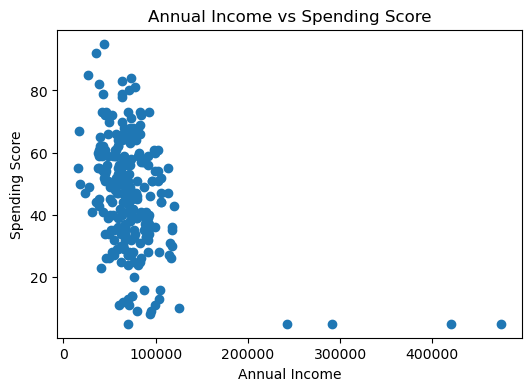

In [12]:
plt.figure(figsize=(6,4))
plt.scatter(df["AnnualIncome"], df["SpendingScore"])
plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

There is no strong linear relationship between income and spending score, suggesting customers with both high and low income can have high spending behavior.

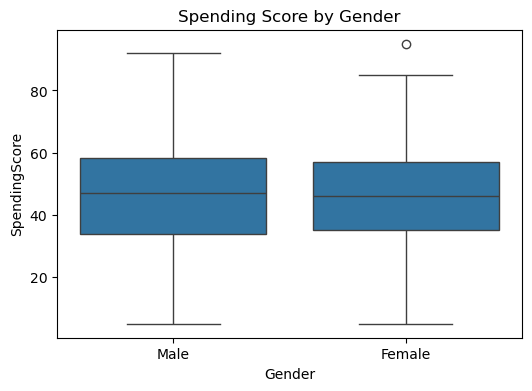

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Gender", y="SpendingScore", data=df)
plt.title("Spending Score by Gender")
plt.show()

Female customers show slightly higher median spending scores compared to male customers.

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Create correlation matrix
correlation_matrix = numeric_df.corr()

correlation_matrix

,CustomerID,Age,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,LastPurchaseAmount
CustomerID,1.000000,-0.038170,-0.039180,0.070869,-0.018877,-0.077040,-0.029642,0.023180,-0.034412
Age,-0.038170,1.000000,-0.051429,-0.006943,0.975242,0.103053,-0.033532,-0.051190,0.092891
AnnualIncome,-0.039180,-0.051429,1.000000,-0.384127,-0.054300,-0.036673,0.096734,-0.114378,-0.016602
SpendingScore,0.070869,-0.006943,-0.384127,1.000000,-0.017487,0.009792,-0.072441,0.057686,0.032737
YearsEmployed,-0.018877,0.975242,-0.054300,-0.017487,1.000000,0.073113,-0.052168,-0.050904,0.114464
PurchaseFrequency,-0.077040,0.103053,-0.036673,0.009792,0.073113,1.000000,-0.041362,0.084121,-0.068246
OnlineVisitsPerMonth,-0.029642,-0.033532,0.096734,-0.072441,-0.052168,-0.041362,1.000000,-0.071400,0.010528
ReturnedItems,0.023180,-0.051190,-0.114378,0.057686,-0.050904,0.084121,-0.071400,1.000000,0.016208
LastPurchaseAmount,-0.034412,0.092891,-0.016602,0.032737,0.114464,-0.068246,0.010528,0.016208,1.000000


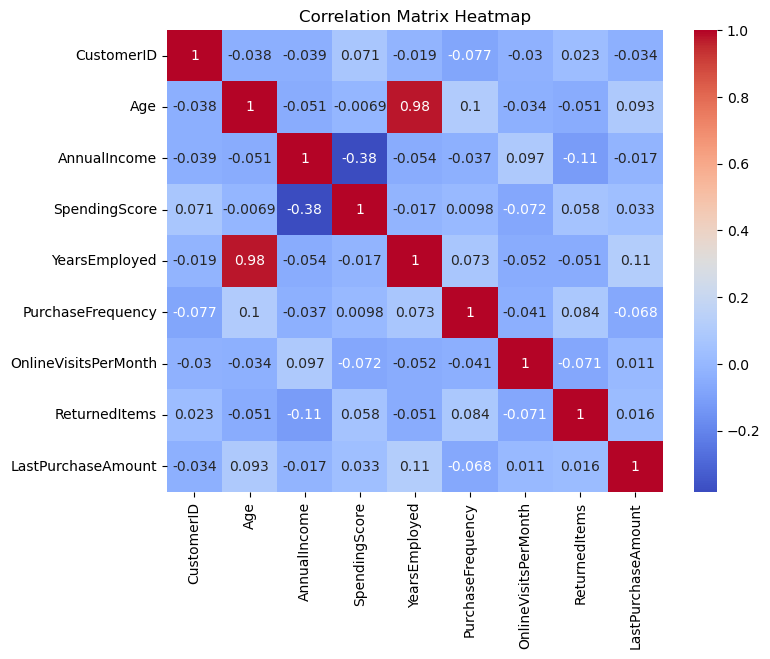

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix Heatmap")
plt.show()

### Correlation Analysis

The heatmap shows the strength and direction of relationships between numerical variables. 
Values close to +1 indicate strong positive correlation, while values close to -1 indicate strong negative correlation. 
This helps identify which variables are strongly related and may influence each other.

Executive Summary
After performing exploratory data analysis, the following key insights were discovered:

Income and Spending Behavior: There is a noticeable relationship between Annual Income and Spending Score, indicating possible customer segmentation opportunities.

Age Patterns: Most customers fall within a specific age group, suggesting that the business primarily attracts a certain demographic.

Gender/Education Impact: Spending behavior varies slightly across categories such as Gender or Education level, which may influence marketing strategies.

Overall, the dataset reveals meaningful relationships between demographic factors and spending patterns, which can be useful for targeted business decisions

In [19]:
df.to_csv("customer_analytics (1)updated.csv", index=False)